In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import   StandardScaler

# Oversampling
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluasi
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv(r'D:\Kitab Suci\Fixxxx belajar\Machine Learning\Dataset\diabetes.csv')
df 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


(768, 9)

In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


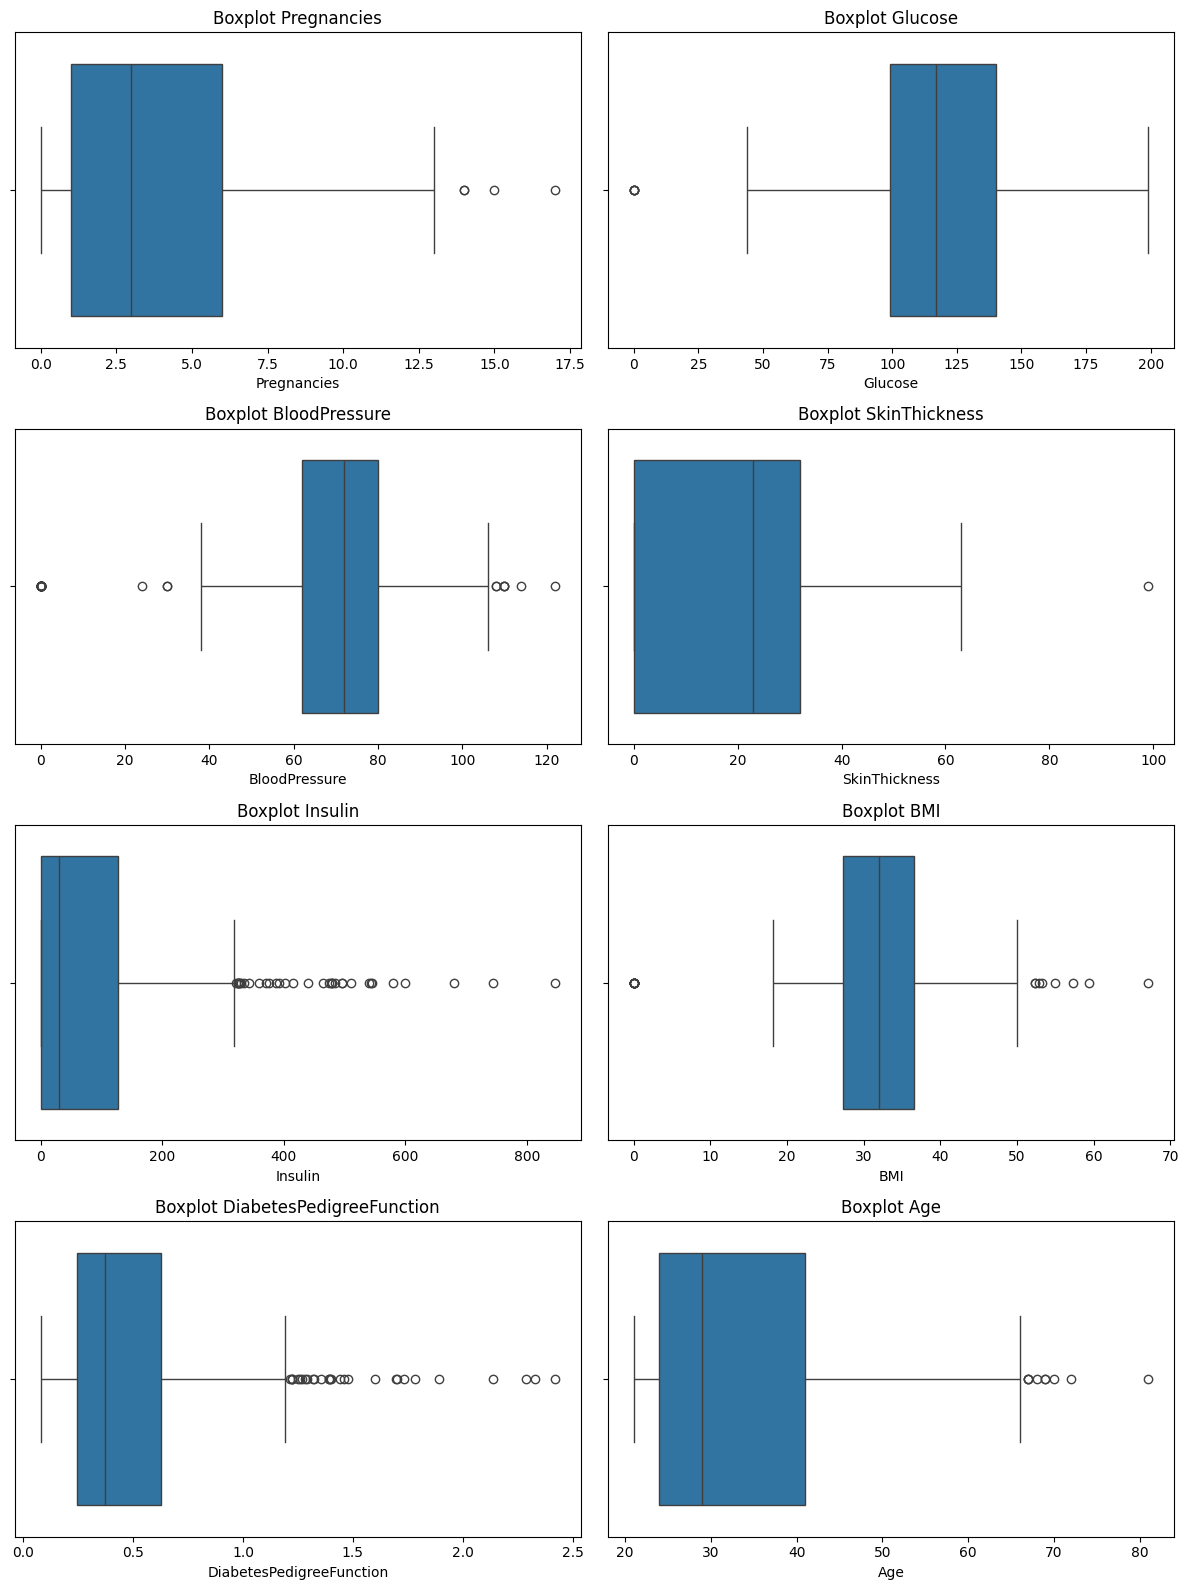

In [6]:
# Cek outlier
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Calculate grid size
n_cols = 2
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')

# Remove unused axes
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [7]:
df['Glucose'] = df['Glucose'].astype(float)
df['BloodPressure'] = df['BloodPressure'].astype(float)
df['BMI'] = df['BMI'].astype(float)

df['Glucose'] = df['Glucose'].replace(0, np.nan)
df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
df['BMI'] = df['BMI'].replace(0, np.nan)
df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)
df['Insulin'] = df['Insulin'].replace(0, np.nan)

df.fillna(df.median(numeric_only=True), inplace=True)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


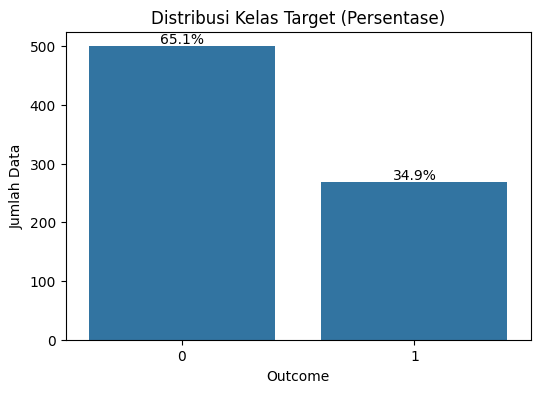

In [8]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Outcome', data=df)

total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom'
    )

plt.title("Distribusi Kelas Target (Persentase)")
plt.ylabel("Jumlah Data")
plt.show()

<Axes: >

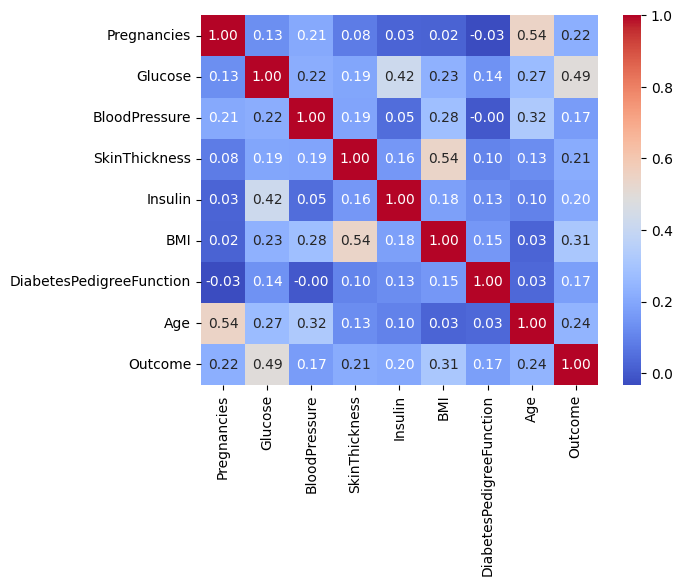

In [9]:
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')

In [10]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

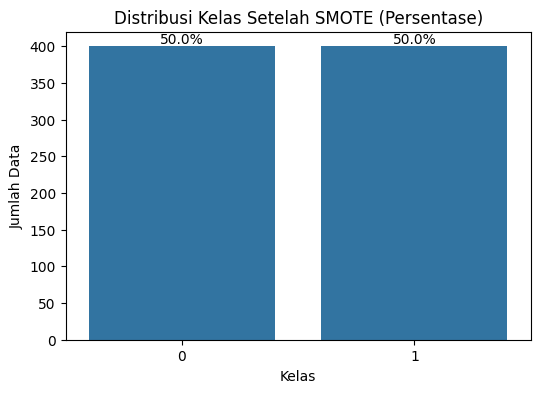

In [11]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y_train_res)
total = len(y_train_res)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom'
    )
plt.title("Distribusi Kelas Setelah SMOTE (Persentase)")
plt.ylabel("Jumlah Data")
plt.xlabel("Kelas")
plt.show()

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

=== Logistic Regression Evaluation ===
Accuracy: 0.7142857142857143

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154



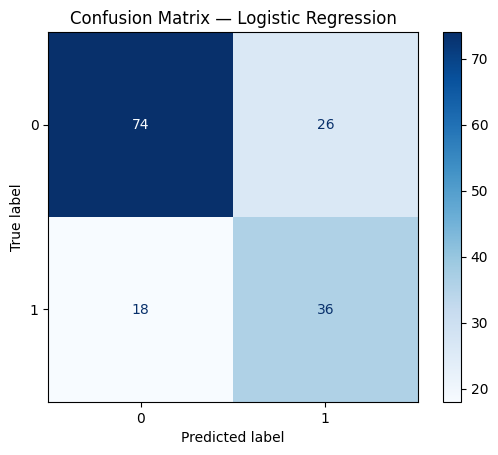

In [13]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train_res)

y_pred_log = log_model.predict(X_test_scaled)
print("=== Logistic Regression Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=log_model.classes_
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


=== KNN Evaluation ===
Accuracy: 0.7207792207792207

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76       100
           1       0.57      0.80      0.67        54

    accuracy                           0.72       154
   macro avg       0.72      0.74      0.71       154
weighted avg       0.76      0.72      0.73       154



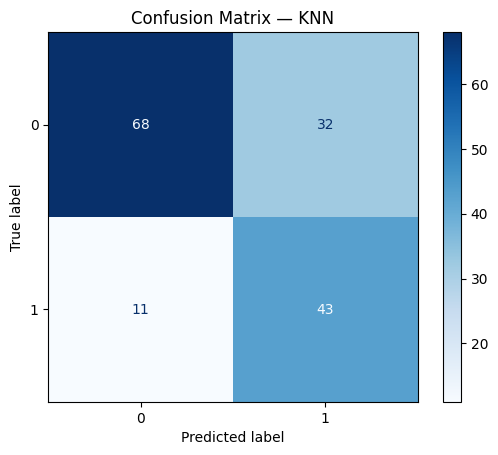

In [14]:
# KNN
knn_model = KNeighborsClassifier(
    n_neighbors=13,
    metric='minkowski'
)

knn_model.fit(X_train_scaled, y_train_res)

y_pred_knn = knn_model.predict(X_test_scaled)

print("=== KNN Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=knn_model.classes_
)
disp_knn.plot(cmap='Blues')
plt.title("Confusion Matrix — KNN")
plt.show()

=== SVM Evaluation ===
Accuracy: 0.7597402597402597

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       100
           1       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



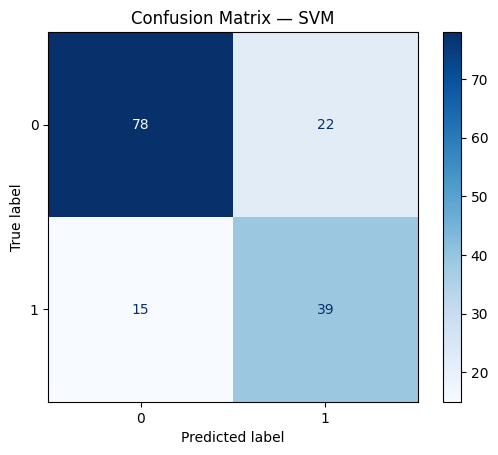

In [15]:
# SVM 
svm_model = SVC(
    kernel='rbf',        
    C=1.0,               
    gamma='scale',      
    random_state=42
)

svm_model.fit(X_train_scaled, y_train_res)
y_pred_svm = svm_model.predict(X_test_scaled)

print("=== SVM Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_model.classes_
)
disp_svm.plot(cmap='Blues')
plt.title("Confusion Matrix — SVM")
plt.show()

In [16]:
def evaluate_model(model, X_test, Y_test):
    y_pred = model.predict(X_test)
    return {
        "Accuracy" : accuracy_score(Y_test, y_pred),
        "Precision": precision_score(Y_test, y_pred, average='weighted'),  # ganti binary → weighted
        "Recall"   : recall_score(Y_test, y_pred, average='weighted'),
        "F1 Score" : f1_score(Y_test, y_pred, average='weighted'),
    }

In [17]:
results = []

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    **evaluate_model(log_model, X_test_scaled, y_test)
})

# KNN
results.append({
    "Model": "KNN",
    **evaluate_model(knn_model, X_test_scaled, y_test)
})

# SVM
results.append({
    "Model": "SVM",
    **evaluate_model(svm_model, X_test_scaled, y_test)
})

In [18]:
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.714286,0.725907,0.714286,0.718186
1,KNN,0.720779,0.759974,0.720779,0.727128
2,SVM,0.759740,0.768802,0.759740,0.762695


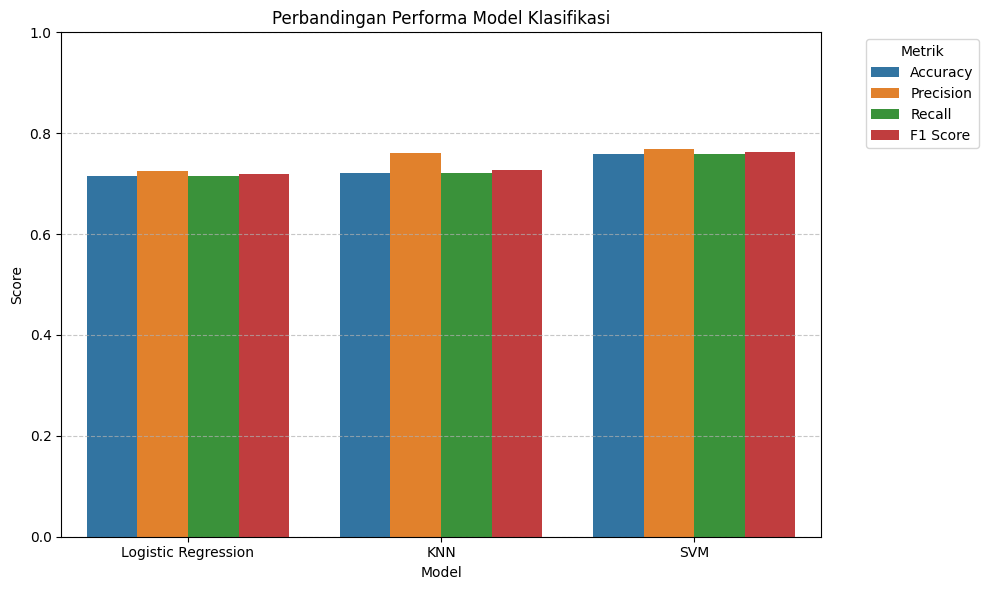

In [19]:
df_melt = comparison_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_melt,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title("Perbandingan Performa Model Klasifikasi")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.legend(title="Metrik", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()